# Redes Neuronales Recurrentes

En este notebook exploraremos distintas arquitecturas de redes neuronales aplicadas a datos del mundo real. Hasta ahora hemos trabajado siempre con el mismo tipo de modelo: el **Perceptrón Multicapa** (MLP), una red *feed-forward* de la que ya conocemos bien su estructura y funcionamiento.

![](https://www.researchgate.net/profile/Mohamed_Zahran6/publication/303875065/figure/fig4/AS:371118507610123@1465492955561/A-hypothetical-example-of-Multilayer-Perceptron-Network.png)

El MLP es un modelo poderoso y versátil, pero tiene una limitación importante: no está diseñado para capturar dependencias temporales en **datos secuenciales**, como series de precios financieros. En este notebook trabajaremos con el dataset `USD_RUB_Historical_Data.csv`, que contiene el historial del tipo de cambio **dólar estadounidense / rublo ruso (USD/RUB)**. Este tipo de datos, en el que cada observación depende de las anteriores, requiere una arquitectura diferente: las **Redes Neuronales Recurrentes** (RNN).


## Definición

En una red neuronal *feed forward* la información viaja en un único sentido: desde la capa de entrada hacia la salida, sin volver atrás. El `MLP` es el ejemplo por excelencia de este tipo. En cambio, una **red recurrente** añade conexiones hacia atrás entre las neuronas, permitiendo que la información de pasos anteriores influya en el procesamiento actual.

![](https://miro.medium.com/max/2544/1*aIT6tmnk3qHpStkOX3gGcQ.png)


La imagen anterior muestra la `RNN` más simple posible: una entrada, una neurona oculta y una salida. En un `MLP` estándar, la salida se calcula como:

$$ \mathbf{y} = \mathbf{W}_y \mathbf{h} = \mathbf{W}_y f(\mathbf{W}_x \mathbf{x}) $$

En una `RNN`, además de la entrada $\mathbf{x}_t$ del instante actual, se incorpora también el estado oculto del instante anterior $\mathbf{h}_{t-1}$, con su propia matriz de pesos:

$$ \mathbf{y}_t = \mathbf{W}_y \mathbf{h}_t = \mathbf{W}_y f(\mathbf{W}_x \mathbf{x}_t + \mathbf{W}_h \mathbf{h}_{t-1}) $$

En nuestro caso, el dataset USD/RUB está compuesto por una secuencia de precios diarios. Cada elemento $\mathbf{x}_t$ representa el precio (y otras características) del día $t$, y la red deberá aprender a utilizar el contexto de los días anteriores para predecir el valor del día siguiente.


## Tipos de RNNs


Las `RNN` abren un nuevo abanico de posibilidades según cómo configuremos las entradas y salidas:

![](https://i.stack.imgur.com/b4sus.jpg)

La configuración *one-to-one* equivale al `MLP` clásico. Las demás permiten trabajar con secuencias: *many-to-one* es ideal para predecir un único valor futuro a partir de una ventana de valores pasados (que es exactamente lo que haremos con el precio USD/RUB), mientras que *many-to-many* permite predecir varios pasos hacia el futuro de forma simultánea.


## Entrenando RNNs

El entrenamiento de las `RNN` sigue el mismo algoritmo que ya conocemos: **backpropagation**. La diferencia es que ahora los gradientes pueden fluir desde múltiples salidas a lo largo del tiempo, lo que se conoce como *backpropagation through time* (BPTT). Esto puede provocar problemas como el **desvanecimiento** o la **explosión del gradiente**, de los que hablaremos más adelante.

![](https://s3.ap-south-1.amazonaws.com/techleer/191.png)

En la práctica, frameworks como PyTorch ya manejan este proceso internamente, por lo que podemos entrenar una `RNN` con los mismos ingredientes que usamos para el `MLP`: un optimizador, una función de pérdida y el bucle de entrenamiento habitual.


## Predicción de series temporales

Ahora que ya tenemos la base teórica, vamos a aplicarla a un problema real. Trabajaremos con el dataset `USD_RUB_Historical_Data.csv`, que contiene precios históricos diarios del tipo de cambio dólar/rublo.Cargaremos los datos, los normalizaremos y construiremos ventanas deslizantes de `n_steps` días para predecir el precio del día siguiente.


In [148]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(15, 8))
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            if ix >= len(series):
                break
            s = series[ix, :, 0]
            plt.plot(s, ".-")
            if y is not None:
                plt.plot([len(s)], y[ix], "bx", markersize=10)
            if y_pred is not None:
                plt.plot([len(s)], y_pred[ix], "ro")
            plt.grid(True)
            plt.hlines(0, 0, len(s) + 2, linewidth=1)
            plt.ylim(s.min() - 0.05, s.max() + 0.05)
            if row == r - 1:
                plt.xlabel(x_label if x_label else "Paso de tiempo", fontsize=12)
            if col == 0:
                plt.ylabel(y_label if y_label else "Precio", fontsize=12, rotation=0, labelpad=40)

    legend_items = [Line2D([0], [0], color='steelblue', marker='.', linestyle='-', label='Historial de precios')]
    if y is not None:
        legend_items.append(Line2D([0], [0], color='blue', marker='x', linestyle='None', markersize=10, label='Precio real del día siguiente'))
    if y_pred is not None:
        legend_items.append(Line2D([0], [0], color='red', marker='o', linestyle='None', markersize=6, label='Predicción del modelo'))
    fig.legend(handles=legend_items, loc='lower center', ncol=len(legend_items), fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.01))

    plt.suptitle("Ventanas de series temporales — USD/RUB", fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

---

### Dataset real: USD/RUB

Una vez visto el ejemplo con datos sintéticos, replicamos el mismo flujo pero ahora con el dataset `USD_RUB_Historical_Data.csv`. Las series ya no son señales sinusoidales controladas, sino el precio histórico real del tipo de cambio dólar/rublo, lo que introduce mayor irregularidad y ruido real de mercado.


In [149]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('USD_RUB_Historical_Data.csv')
df = df.drop(columns=['Vol.'])

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")


        Date   Price     Open     High      Low  Change %
0 2007-01-01  26.305  26.3255  26.3255  26.3095     -0.06
1 2007-01-02  26.305  26.3100  26.3100  26.3095      0.00
2 2007-01-03  26.305  26.3100  26.3100  26.3095      0.00
3 2007-01-04  26.382  26.3100  26.3965  26.3083      0.29
4 2007-01-05  26.382  26.3845  26.3845  26.3845      0.00

Shape: (5014, 6)

Columnas: ['Date', 'Price', 'Open', 'High', 'Low', 'Change %']


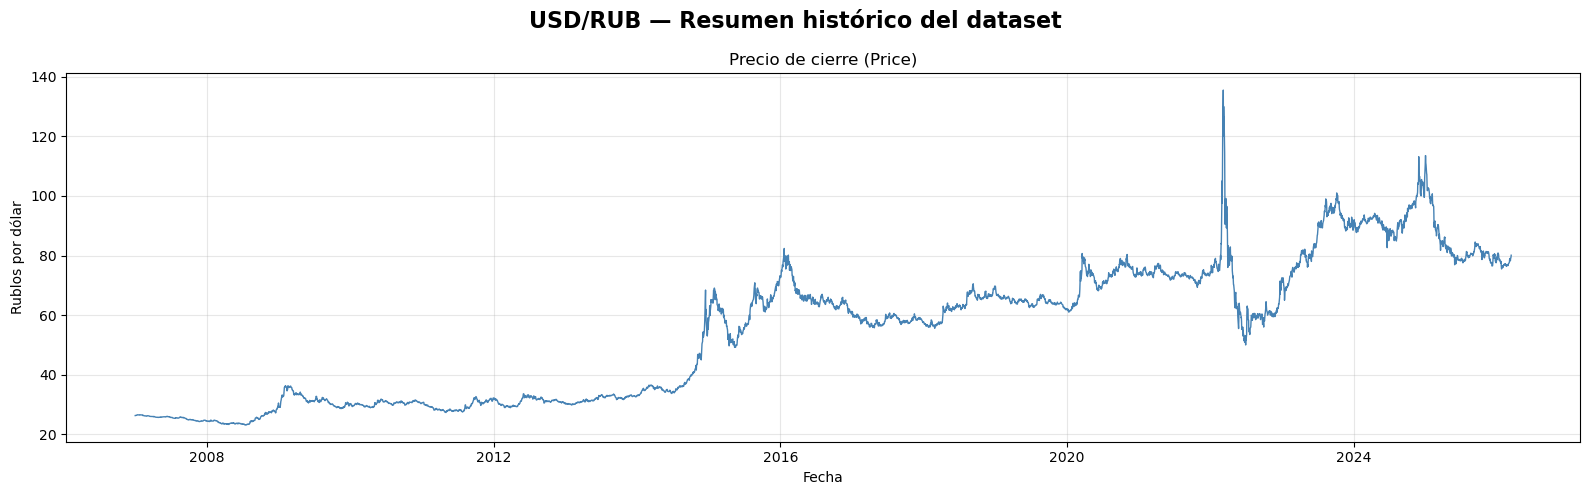

In [150]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
fig.suptitle('USD/RUB — Resumen histórico del dataset', fontsize=16, fontweight='bold')

ax.plot(df['Date'], df['Price'], color='steelblue', linewidth=1)
ax.set_title('Precio de cierre (Price)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Rublos por dólar')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [151]:
scaler = MinMaxScaler()
features = ['Price','Open','High','Low','Change %']
data = scaler.fit_transform(df[features])

n_steps = 30

def create_sequences(data, n_steps, target_idx=0):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i + n_steps])
        y.append(data[i + n_steps, target_idx])
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32).reshape(-1, 1))

sequences, targets = create_sequences(data, n_steps)

n = len(sequences)
n_train = int(0.7 * n)
n_valid = int(0.2 * n)

X_train, y_train = sequences[:n_train],               targets[:n_train]
X_valid, y_valid = sequences[n_train:n_train+n_valid], targets[n_train:n_train+n_valid]
X_test,  y_test  = sequences[n_train+n_valid:],        targets[n_train+n_valid:]

print(f"Train: {X_train.shape},  {y_train.shape}")
print(f"Valid: {X_valid.shape},  {y_valid.shape}")
print(f"Test:  {X_test.shape},   {y_test.shape}")


Train: (3488, 30, 5),  (3488, 1)
Valid: (996, 30, 5),  (996, 1)
Test:  (500, 30, 5),   (500, 1)


In [152]:
print(df.describe())


                                Date        Price         Open         High  \
count                           5014  5014.000000  5014.000000  5014.000000   
mean   2016-08-07 06:21:06.533705728    54.617623    54.724883    55.312535   
min              2007-01-01 00:00:00    23.153100    23.157400    23.203500   
25%              2011-10-20 06:00:00    31.060350    31.052500    31.211225   
50%              2016-08-09 12:00:00    59.343000    59.564350    60.427200   
75%              2021-05-24 18:00:00    73.080000    73.267800    73.788275   
max              2026-03-13 00:00:00   135.500000   135.500000   158.300000   
std                              NaN    22.729827    22.824575    23.310682   

               Low     Change %  
count  5014.000000  5014.000000  
mean     54.183935     0.029962  
min      23.055000   -13.540000  
25%      30.923425    -0.420000  
50%      58.954800     0.000000  
75%      72.776700     0.450000  
max     125.500000    20.430000  
std      22.3896

Nuestro objetivo es **predecir el precio de cierre del día siguiente** a partir de los `n_steps` días anteriores. Si un modelo logra hacer esto con precisión, podría ser útil como señal en estrategias de análisis financiero o para monitorear la volatilidad del tipo de cambio USD/RUB.


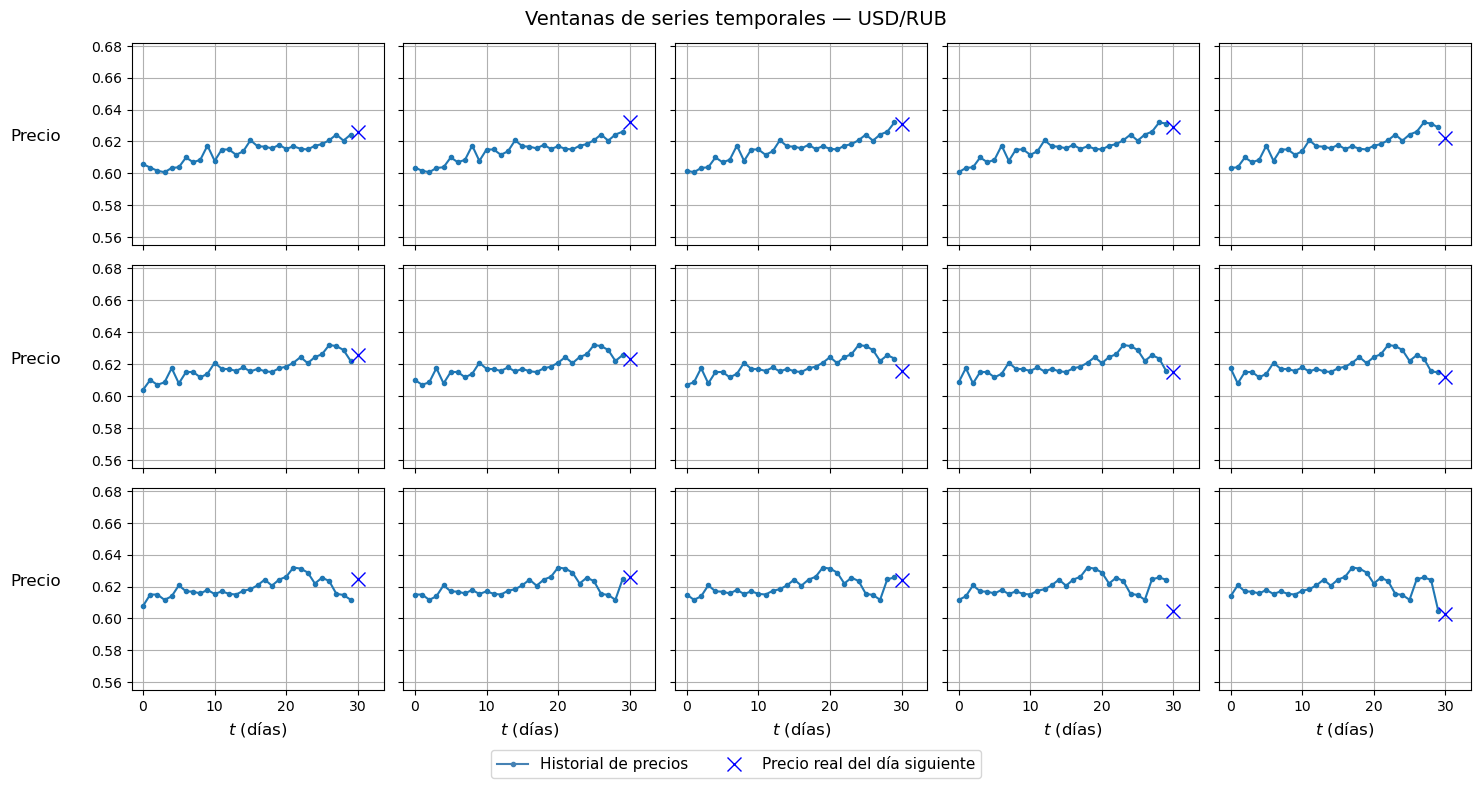

In [163]:
# Visualizar 15 ventanas del conjunto de prueba USD/RUB con su valor objetivo (cruz azul)
# El eje Y muestra el precio normalizado [0, 1]; la 'x' azul es el precio real del día siguiente
plot_series(X_test, y_test, x_label="$t$ (días)", y_label="Precio")


### Predicción *Naive*

Un modelo de referencia muy sencillo consiste en predecir que el precio del día siguiente será igual al precio del último día conocido. A pesar de su simplicidad, este modelo puede ser difícil de superar en series financieras con poca volatilidad a corto plazo.


In [154]:
from sklearn.metrics import mean_squared_error

# Predicción naive: el precio del día siguiente = último precio conocido de la ventana
y_pred_naive = X_test[:, -1, 0].reshape(-1, 1)
mean_squared_error(y_test, y_pred_naive)


0.0001012635839288123

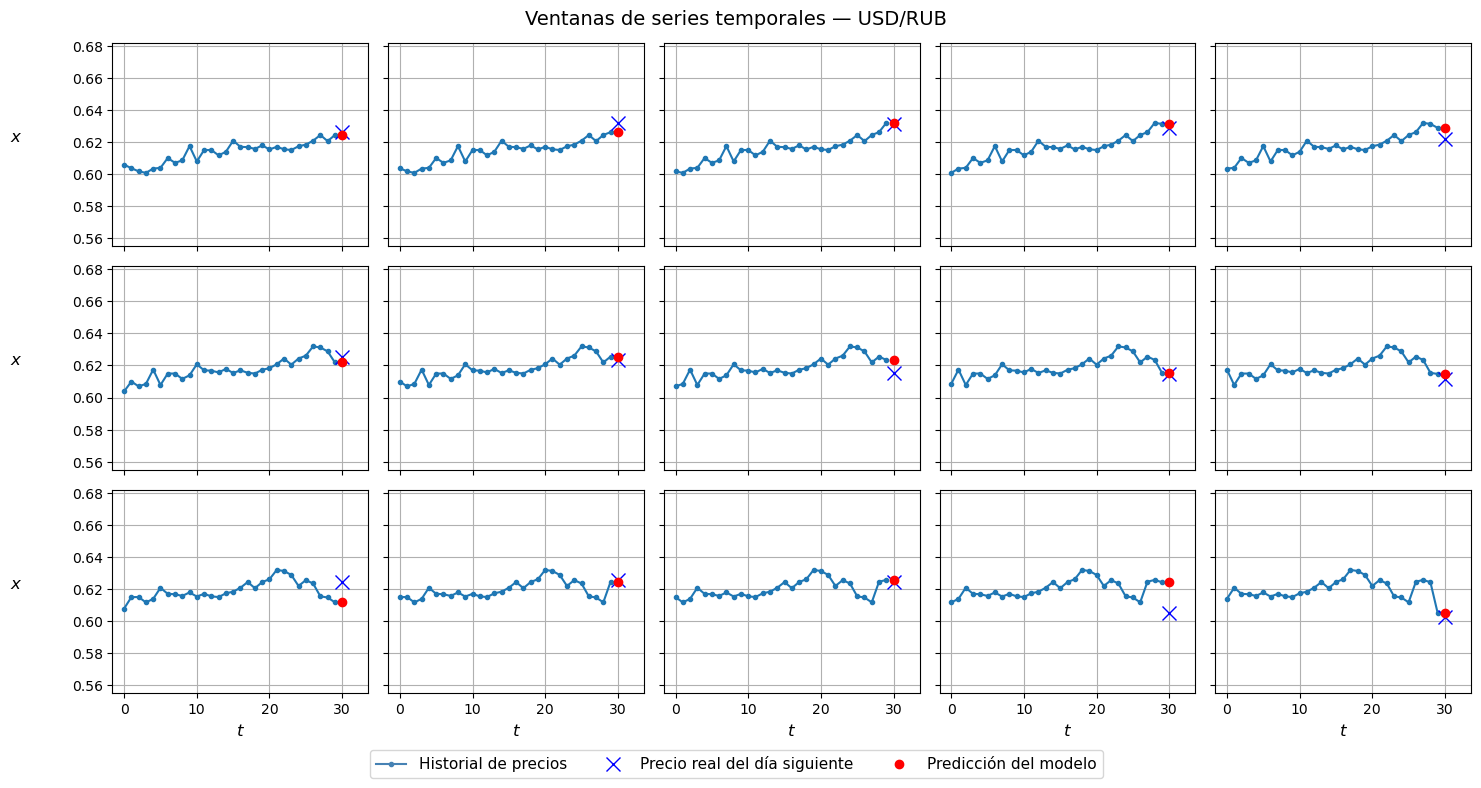

In [155]:
plot_series(X_test, y_test, y_pred_naive)


Como se puede ver, este modelo tan simple tiene un rendimiento razonable: en series financieras, el precio del día anterior suele ser una buena estimación del precio del día siguiente. Este resultado es el **umbral mínimo** que cualquier modelo más complejo debería superar.


### Perceptrón Multicapa

Dado que todas las ventanas tienen la misma longitud (`n_steps`), podemos intentar resolver el problema con un `MLP` estándar. Aunque no captura dependencias temporales de forma explícita, puede aprender correlaciones lineales útiles si los patrones son suficientemente regulares.


In [156]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
  def __init__(self, X, y=None, train=True):
    self.X = X
    self.y = y
    self.train = train

  def __len__(self):
    return len(self.X)

  def __getitem__(self, ix):
    if self.train:
      return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
    return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, y_train),
    'eval': TimeSeriesDataset(X_valid, y_valid),
    'test': TimeSeriesDataset(X_test, y_test, train=False)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=False, batch_size=64),
    'eval': DataLoader(dataset['eval'], shuffle=False, batch_size=64),
    'test': DataLoader(dataset['test'], shuffle=False, batch_size=64)
}

In [157]:
class MLP(torch.nn.Module):
  def __init__(self, n_steps=30, n_features=5, n_out=1):
    super().__init__()
    self.fc = torch.nn.Linear(n_steps * n_features, n_out)

  def forward(self, x):
    x = x.view(x.shape[0], -1)
    x = self.fc(x)
    return x

mlp = MLP(n_steps=n_steps, n_features=X_train.shape[2])
mlp

MLP(
  (fc): Linear(in_features=150, out_features=1, bias=True)
)

In [158]:
from tqdm import tqdm
device = "cuda" if torch.cuda.is_available() else "cpu"

def fit(model, dataloader, epochs=150, scheduler=None, early_stopping=0):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs+1))
    best_loss, step = float('inf'), 0
    
    for epoch in bar:
        model.train()
        train_loss, train_acc = [], []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            train_acc.append((torch.abs(y_hat - y) < 0.05).float().mean().item())
        
        model.eval()
        eval_loss, eval_acc = [], []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                eval_loss.append(loss.item())
                eval_acc.append((torch.abs(y_hat - y) < 0.05).float().mean().item())
        
        mean_train_loss = np.mean(train_loss)
        mean_eval_loss = np.mean(eval_loss)
        mean_train_acc = np.mean(train_acc)
        mean_eval_acc = np.mean(eval_acc)
        bar.set_description(f"loss {mean_train_loss:.5f} val_loss {mean_eval_loss:.5f} acc {mean_train_acc:.5f} val_acc {mean_eval_acc:.5f}")
        
        scheduler.step(mean_eval_loss)
        
        if mean_eval_loss < best_loss:
            best_loss = mean_eval_loss
            step = 0
        else:
            step += 1
        
        if early_stopping and step > early_stopping:
            break

def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X = batch
            X = X.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
        return preds

In [159]:
fit(mlp, dataloader)

d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
loss 0.00014 val_loss 0.00152 acc 0.99290 val_acc 0.93848: 100%|██████████| 150/150 [00:16<00:00,  9.34it/s]


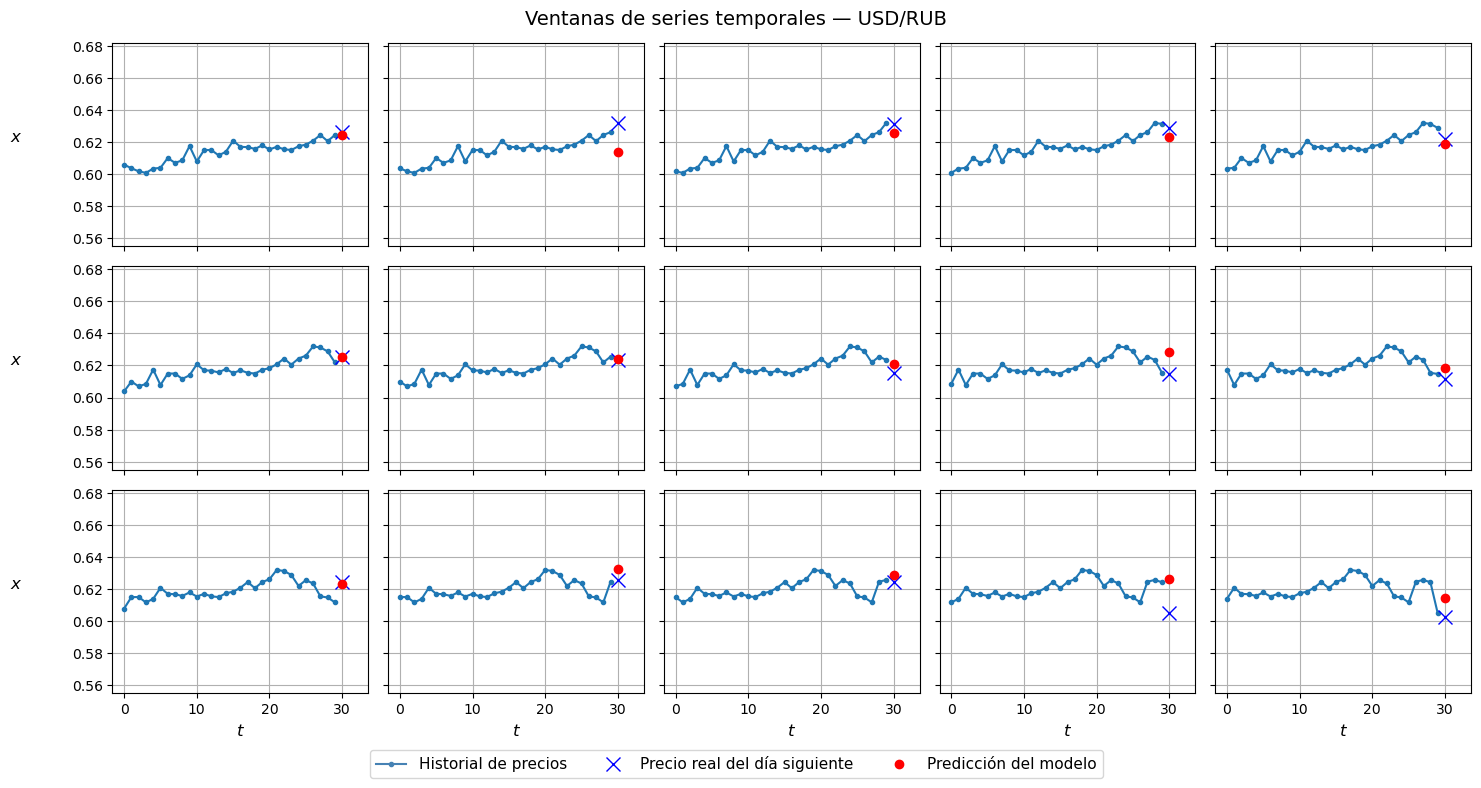

0.00041674895328469574

In [160]:
y_pred = predict(mlp, dataloader['test'])
plot_series(X_test, y_test, y_pred.cpu().numpy())
mean_squared_error(y_test, y_pred.cpu().numpy())


El `MLP` logra mejorar (o al menos igualar) la predicción ingenua. Este modelo es más práctico para **pronóstico autoregresivo**, donde cada predicción se usa como entrada para el siguiente día, permitiendo proyectar indefinidamente hacia el futuro.

## Pronóstico Futuro: Predicción Autoregresiva

Implementamos un enfoque **many-to-one autoregresivo**, este diseño es más práctico para **predecir valores futuros** porque permite generar pronósticos a cualquier horizonte mediante iteración: cada predicción se usa como entrada para el siguiente día, sin limitarse a los datos conocidos del dataset.

In [161]:
horizon = 30

last_window = data[-n_steps:].astype(np.float32).copy()
future_scaled = []

mlp.eval()
for _ in range(horizon):
    x_in = torch.from_numpy(last_window).unsqueeze(0).to(device=device, dtype=torch.float32)
    
    with torch.no_grad():
        next_scaled = mlp(x_in).item()
    
    next_scaled = float(np.clip(next_scaled, 0.0, 1.0))
    future_scaled.append(next_scaled)
    
    new_row = last_window[-1].copy().reshape(1, -1)
    new_row[0, 0] = next_scaled
    last_window = np.concatenate([last_window[1:], new_row], axis=0).astype(np.float32)

price_min = scaler.data_min_[0]
price_range = scaler.data_range_[0]
future_prices = np.array(future_scaled) * price_range + price_min

today = pd.Timestamp('2026-03-13')
future_dates = pd.date_range(start=today + pd.Timedelta(days=1), periods=horizon, freq='D')

future_df = pd.DataFrame({
    'Date': future_dates,
    'Prediccion_USD_RUB': future_prices,
})

print(f"PRONÓSTICO A {horizon} DÍAS - MODELO MLP")
print(future_df)
print(f"\nÚltimo precio histórico (13 de marzo 2026): {df['Price'].iloc[-1]:.4f} RUB/USD")
print(f"Precio predicho día {horizon}: {future_df['Prediccion_USD_RUB'].iloc[-1]:.4f} RUB/USD")


PRONÓSTICO A 30 DÍAS - MODELO MLP
         Date  Prediccion_USD_RUB
0  2026-03-14           78.504353
1  2026-03-15           78.700932
2  2026-03-16           79.236115
3  2026-03-17           79.183348
4  2026-03-18           80.001520
5  2026-03-19           79.599288
6  2026-03-20           79.826784
7  2026-03-21           79.870686
8  2026-03-22           80.640698
9  2026-03-23           81.053504
10 2026-03-24           80.806581
11 2026-03-25           80.948049
12 2026-03-26           80.481002
13 2026-03-27           80.806568
14 2026-03-28           80.827748
15 2026-03-29           80.908848
16 2026-03-30           79.989125
17 2026-03-31           80.308148
18 2026-04-01           80.278296
19 2026-04-02           79.947534
20 2026-04-03           80.752568
21 2026-04-04           79.757872
22 2026-04-05           80.295244
23 2026-04-06           80.387929
24 2026-04-07           80.210943
25 2026-04-08           80.399045
26 2026-04-09           80.496437
27 2026-04-10 


Últimos 180 registros: desde 2025-07-07 hasta 2026-03-13


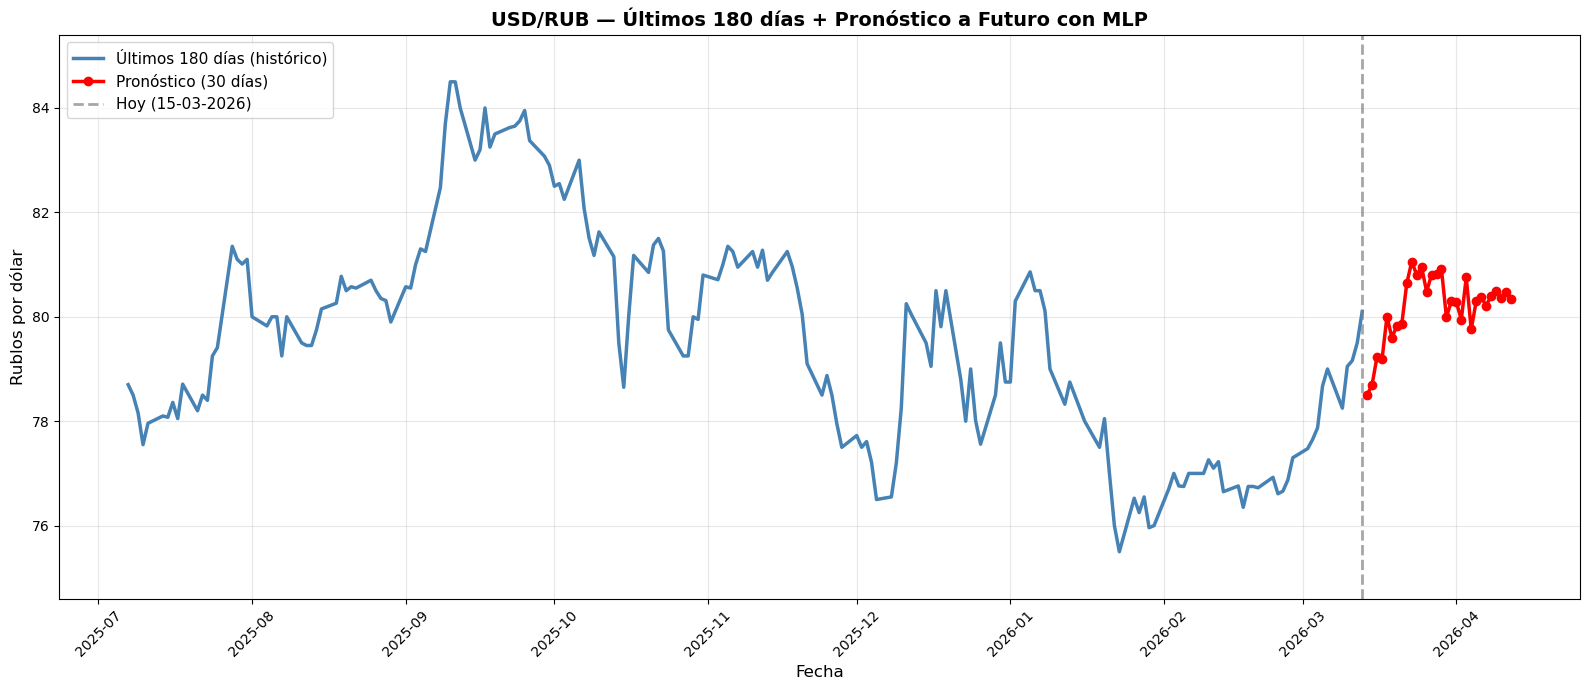

In [162]:
plt.figure(figsize=(16, 7))

today = pd.Timestamp('2026-03-13')

historical_recent = df.tail(180)

print(f"\nÚltimos 180 registros: desde {historical_recent['Date'].iloc[0].date()} hasta {historical_recent['Date'].iloc[-1].date()}")

plt.plot(historical_recent['Date'], historical_recent['Price'], linewidth=2.5, color='steelblue', label='Últimos 180 días (histórico)')

plt.plot(future_df['Date'], future_df['Prediccion_USD_RUB'], 'o-', 
         linewidth=2.5, color='red', markersize=6, label='Pronóstico (30 días)')

plt.axvline(today, color='gray', linestyle='--', alpha=0.7, linewidth=2, label='Hoy (15-03-2026)')

all_prices = np.concatenate([historical_recent['Price'].values, future_df['Prediccion_USD_RUB'].values])
y_min, y_max = all_prices.min(), all_prices.max()
y_margin = (y_max - y_min) * 0.1
plt.ylim(y_min - y_margin, y_max + y_margin)

plt.title('USD/RUB — Últimos 180 días + Pronóstico a Futuro con MLP', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Rublos por dólar', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()